In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Lab 5: Xây dựng mô hình RNN cho bài toán PoS Tagging

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.8.0+cu126


## Task 1:

In [3]:
def load_conllu(file_path):
    sentences = []
    current_sentence = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if line.startswith('#') or line == '':
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
                continue

            parts = line.split('\t')
            if len(parts) >= 4:
                word = parts[1]
                upos_tag = parts[3]
                current_sentence.append((word, upos_tag))

    if current_sentence:
        sentences.append(current_sentence)

    return sentences

def build_vocabularies(sentences, min_word_freq=1):
    word_counter = Counter()
    tag_counter = Counter()

    for sentence in sentences:
        for word, tag in sentence:
            word_counter[word] += 1
            tag_counter[tag] += 1

    word_to_ix = {'<PAD>': 0, '<UNK>': 1}
    for word, count in word_counter.items():
        if count >= min_word_freq:
            word_to_ix[word] = len(word_to_ix)

    tag_to_ix = {'<PAD>': 0}
    for tag in tag_counter.keys():
        tag_to_ix[tag] = len(tag_to_ix)

    return word_to_ix, tag_to_ix



train_sentences = load_conllu('/content/drive/MyDrive/Datasets/en_ewt-ud-train.conllu')
dev_sentences = load_conllu('/content/drive/MyDrive/Datasets/en_ewt-ud-dev.conllu')
test_sentences = load_conllu('/content/drive/MyDrive/Datasets/en_ewt-ud-test.conllu')

word_to_ix, tag_to_ix = build_vocabularies(train_sentences)

print(f"train: {len(train_sentences)}")
print(f"dev: {len(dev_sentences)}")
print(f"Kich thuoc tu dien tu: {len(word_to_ix)}")
print(f"Kich thuoc tu dien nhan: {len(tag_to_ix)}")

train: 12544
dev: 2001
Kich thuoc tu dien tu: 20202
Kich thuoc tu dien nhan: 19


## Task 2: Tạo Pytorch dataset và DataLoader

In [4]:
class POSDataset(Dataset):
    def __init__(self, sentences, word_to_ix, tag_to_ix):
        self.sentences = sentences
        self.word_to_ix = word_to_ix
        self.tag_to_ix = tag_to_ix

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        sentence_indices = [self.word_to_ix.get(word, self.word_to_ix['<UNK>']) for word, _ in sentence]
        tag_indices = [self.tag_to_ix[tag] for _, tag in sentence]
        return torch.tensor(sentence_indices, dtype=torch.long), torch.tensor(tag_indices, dtype=torch.long)

def collate_fn(batch):
    sentences, tags = zip(*batch)

    padded_sentences = torch.nn.utils.rnn.pad_sequence(
        sentences, batch_first=True, padding_value=word_to_ix['<PAD>']
    )
    padded_tags = torch.nn.utils.rnn.pad_sequence(
        tags, batch_first=True, padding_value=tag_to_ix['<PAD>']
    )
    lengths = torch.tensor([len(sent) for sent in sentences], dtype=torch.long)

    return padded_sentences, padded_tags, lengths

train_dataset = POSDataset(train_sentences, word_to_ix, tag_to_ix)
dev_dataset = POSDataset(dev_sentences, word_to_ix, tag_to_ix)

batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"Kich thuoc train dataset: {len(train_dataset)}")
print(f"Kich thuoc dev dataset: {len(dev_dataset)}")
print(f"Batch size: {batch_size}")
print(f"So luong batch train: {len(train_loader)}")
print(f"So luong batch dev: {len(dev_loader)}")

print("\nTEST BATCH:")
sample_batch = next(iter(train_loader))
padded_sentences, padded_tags, lengths = sample_batch

print(f"Padded sentences shape: {padded_sentences.shape}")
print(f"Padded tags shape: {padded_tags.shape}")
print(f"Lengths: {lengths}")
print(f"Sample sentence: {padded_sentences[0]}")
print(f"Sample tags: {padded_tags[0]}")
print(f"Actual length: {lengths[0]}")

ix_to_word = {v: k for k, v in word_to_ix.items()}
ix_to_tag = {v: k for k, v in tag_to_ix.items()}

sample_sent = [ix_to_word[idx.item()] for idx in padded_sentences[0][:lengths[0]]]
sample_tags = [ix_to_tag[idx.item()] for idx in padded_tags[0][:lengths[0]]]
print(f"Words: {sample_sent}")
print(f"Tags:  {sample_tags}")

Kich thuoc train dataset: 12544
Kich thuoc dev dataset: 2001
Batch size: 32
So luong batch train: 392
So luong batch dev: 63

TEST BATCH:
Padded sentences shape: torch.Size([32, 41])
Padded tags shape: torch.Size([32, 41])
Lengths: tensor([12, 39, 14, 25, 16,  2, 11,  6, 12,  8, 18, 21, 27,  6, 11, 14, 11, 39,
         4, 10, 14,  2, 16, 24, 27, 14,  6, 41, 26, 25, 14, 18])
Sample sentence: tensor([  745,  1484,  1485,   124, 16595,   543,  2288,  5167,    39,   470,
          435,    25,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0])
Sample tags: tensor([ 9, 15,  8, 10,  5,  6,  4,  5, 10,  5, 13,  2,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0])
Actual length: 12
Words: ['We', "can't", 'ca', "n't", 'dictate', 'what', 'bu

## Task 3: Xây dựng mô hình RNN

In [5]:
class SimpleRNNForTokenClassification(nn.Module):
    def __init__(self, vocab_size, tag_vocab_size, embedding_dim=64, hidden_dim=128):
        super(SimpleRNNForTokenClassification, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=word_to_ix['<PAD>'])
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=False
        )
        self.hidden2tag = nn.Linear(hidden_dim, tag_vocab_size)
        self.dropout = nn.Dropout(0.3)

    def forward(self, sentences, lengths=None):
        embeds = self.embedding(sentences)
        embeds = self.dropout(embeds)
        rnn_out, hidden = self.rnn(embeds)
        rnn_out = self.dropout(rnn_out)
        tag_scores = self.hidden2tag(rnn_out)
        return tag_scores

vocab_size = len(word_to_ix)
tag_vocab_size = len(tag_to_ix)
embedding_dim = 64
hidden_dim = 128

model = SimpleRNNForTokenClassification(
    vocab_size=vocab_size,
    tag_vocab_size=tag_vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim
)

model = model.to(device)

print(model)
print(f"Para: {sum(p.numel() for p in model.parameters()):,}")
print(f"Train para: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

SimpleRNNForTokenClassification(
  (embedding): Embedding(20202, 64, padding_idx=0)
  (rnn): RNN(64, 128, batch_first=True)
  (hidden2tag): Linear(in_features=128, out_features=19, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Para: 1,320,211
Train para: 1,320,211


## Task 4: Huấn luyện mô hình

In [6]:
learning_rate = 1e-3
num_epochs = 20
print_every = 1
patience = 2

# Loss function và optimizer
# ignore_index=0 de bo qua các token padding khi tinh loss
criterion = nn.CrossEntropyLoss(ignore_index=tag_to_ix['<PAD>'])
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# Hàm tính accuracy
def calculate_accuracy(predictions, targets, lengths):
    """
    Tính accuracy, chỉ tính trên các token không phải padding
    """
    total_correct = 0
    total_tokens = 0

    for i, length in enumerate(lengths):
        pred = predictions[i, :length]
        target = targets[i, :length]
        pred_tags = torch.argmax(pred, dim=1)
        correct = (pred_tags == target).sum().item()
        total_correct += correct
        total_tokens += length.item()

    return total_correct / total_tokens if total_tokens > 0 else 0
train_losses = []
train_accuracies = []
dev_accuracies = []
best_dev_accuracy = 0
epochs_without_improvement = 0

print("BAT DAU HUAN LUYEN:")
print(f"Device: {device}")
print(f"So epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"Early stopping patience: {patience}")
print("-" * 50)

for epoch in range(num_epochs):
    model.train()

    total_loss = 0
    total_batches = 0
    epoch_train_correct = 0
    epoch_train_total = 0

    for batch_sentences, batch_tags, batch_lengths in train_loader:
        batch_sentences = batch_sentences.to(device)
        batch_tags = batch_tags.to(device)

        optimizer.zero_grad()

        outputs = model(batch_sentences, batch_lengths)

        batch_size_cur, seq_len, num_classes = outputs.shape
        outputs_reshaped = outputs.view(-1, num_classes)
        tags_reshaped = batch_tags.view(-1)

        loss = criterion(outputs_reshaped, tags_reshaped)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        total_batches += 1

        batch_accuracy = calculate_accuracy(outputs, batch_tags, batch_lengths)
        epoch_train_correct += batch_accuracy * batch_lengths.sum().item()
        epoch_train_total += batch_lengths.sum().item()

    avg_loss = total_loss / total_batches
    train_losses.append(avg_loss)
    train_accuracy = epoch_train_correct / epoch_train_total if epoch_train_total > 0 else 0
    train_accuracies.append(train_accuracy)

    model.eval()
    dev_accuracy = 0
    dev_batches = 0

    with torch.no_grad():
        for batch_sentences, batch_tags, batch_lengths in dev_loader:
            batch_sentences = batch_sentences.to(device)
            batch_tags = batch_tags.to(device)

            outputs = model(batch_sentences, batch_lengths)

            batch_accuracy = calculate_accuracy(outputs, batch_tags, batch_lengths)
            dev_accuracy += batch_accuracy
            dev_batches += 1

    avg_dev_accuracy = dev_accuracy / dev_batches if dev_batches > 0 else 0
    dev_accuracies.append(avg_dev_accuracy)

    scheduler.step(avg_dev_accuracy)

    if avg_dev_accuracy > best_dev_accuracy:
        best_dev_accuracy = avg_dev_accuracy
        epochs_without_improvement = 0
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_accuracy': best_dev_accuracy,
                'word_to_ix': word_to_ix,
                'tag_to_ix': tag_to_ix,
            },
            'best_pos_model.pth',
        )
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d}/{num_epochs:3d} | "
            f"Loss: {avg_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Dev Acc: {avg_dev_accuracy:.4f} | "
            f"Best: {best_dev_accuracy:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping after {epoch+1} epoch")
        print(f"Best dev accuracy: {best_dev_accuracy:.4f}")
        break

print("END")
print(f"Best dev accuracy: {best_dev_accuracy:.4f}")

BAT DAU HUAN LUYEN:
Device: cuda
So epochs: 20
Batch size: 32
Learning rate: 0.001
Early stopping patience: 2
--------------------------------------------------
Epoch   1/ 20 | Loss: 1.5131 | Train Acc: 0.5423 | Dev Acc: 0.6653 | Best: 0.6653
Epoch   2/ 20 | Loss: 1.0280 | Train Acc: 0.6776 | Dev Acc: 0.7278 | Best: 0.7278
Epoch   3/ 20 | Loss: 0.8548 | Train Acc: 0.7283 | Dev Acc: 0.7636 | Best: 0.7636
Epoch   4/ 20 | Loss: 0.7389 | Train Acc: 0.7652 | Dev Acc: 0.7870 | Best: 0.7870
Epoch   5/ 20 | Loss: 0.6554 | Train Acc: 0.7915 | Dev Acc: 0.8068 | Best: 0.8068
Epoch   6/ 20 | Loss: 0.5922 | Train Acc: 0.8128 | Dev Acc: 0.8184 | Best: 0.8184
Epoch   7/ 20 | Loss: 0.5359 | Train Acc: 0.8302 | Dev Acc: 0.8293 | Best: 0.8293
Epoch   8/ 20 | Loss: 0.4915 | Train Acc: 0.8437 | Dev Acc: 0.8392 | Best: 0.8392
Epoch   9/ 20 | Loss: 0.4549 | Train Acc: 0.8553 | Dev Acc: 0.8460 | Best: 0.8460
Epoch  10/ 20 | Loss: 0.4234 | Train Acc: 0.8656 | Dev Acc: 0.8513 | Best: 0.8513
Epoch  11/ 20 | Los

## Task 5: Đánh giá mô hình

In [7]:
def evaluate_model(model, data_loader, device, tag_to_ix):
    model.eval()
    total_accuracy = 0
    num_batches = 0

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch_sentences, batch_tags, batch_lengths in data_loader:
            batch_sentences = batch_sentences.to(device)
            batch_tags = batch_tags.to(device)

            outputs = model(batch_sentences, batch_lengths)

            predictions = torch.argmax(outputs, dim=2)

            batch_accuracy = calculate_accuracy(outputs, batch_tags, batch_lengths)
            total_accuracy += batch_accuracy
            num_batches += 1

            for i, length in enumerate(batch_lengths):
                pred_tags = predictions[i, :length].cpu().numpy()
                true_tags = batch_tags[i, :length].cpu().numpy()

                all_predictions.extend(pred_tags)
                all_targets.extend(true_tags)

    overall_accuracy = total_accuracy / num_batches if num_batches > 0 else 0

    return overall_accuracy, all_predictions, all_targets

ix_to_tag = {v: k for k, v in tag_to_ix.items()}

if os.path.exists('best_pos_model.pth'):
    checkpoint = torch.load('best_pos_model.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model with accuracy: {checkpoint['best_accuracy']:.4f}")



train_acc, train_preds, train_targets = evaluate_model(model, train_loader, device, tag_to_ix)
dev_acc, dev_preds, dev_targets = evaluate_model(model, dev_loader, device, tag_to_ix)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Dev Accuracy: {dev_acc:.4f}")
print(f"Best Dev Accuracy (từ training): {best_dev_accuracy:.4f}")

pad_idx = tag_to_ix['<PAD>']
train_preds_filtered = [p for p, t in zip(train_preds, train_targets) if t != pad_idx]
train_targets_filtered = [t for t in train_targets if t != pad_idx]
dev_preds_filtered = [p for p, t in zip(dev_preds, dev_targets) if t != pad_idx]
dev_targets_filtered = [t for t in dev_targets if t != pad_idx]

tag_names = [ix_to_tag[i] for i in range(len(ix_to_tag)) if i != pad_idx]

print("Train set:")
print(classification_report(train_targets_filtered, train_preds_filtered,
                          target_names=tag_names, zero_division=0))

print("DEV SET:")
print(classification_report(dev_targets_filtered, dev_preds_filtered,
                          target_names=tag_names, zero_division=0))

Loaded best model with accuracy: 0.8765
Train Accuracy: 0.9444
Dev Accuracy: 0.8765
Best Dev Accuracy (từ training): 0.8765
Train set:
              precision    recall  f1-score   support

       PROPN       0.91      0.94      0.92     12325
       PUNCT       0.99      1.00      0.99     23597
         ADJ       0.91      0.93      0.92     13152
        NOUN       0.95      0.97      0.96     34813
        VERB       0.94      0.94      0.94     22594
         DET       0.97      0.97      0.97     16299
         ADP       0.88      0.96      0.92     17795
         AUX       0.97      0.94      0.95     12828
        PRON       0.97      0.97      0.97     18642
        PART       0.94      0.93      0.93      5748
       SCONJ       0.83      0.62      0.71      3839
         NUM       0.97      0.93      0.95      4126
         ADV       0.93      0.85      0.89     10113
       CCONJ       0.99      0.99      0.99      6688
           _       0.98      0.82      0.89      2613


In [8]:
def predict_sentence(model, sentence, word_to_ix, tag_to_ix, ix_to_tag, device, max_length=50):
    model.eval()

    tokens = sentence.split()
    if len(tokens) > max_length:
        tokens = tokens[:max_length]

    token_indices = [word_to_ix.get(token, word_to_ix['<UNK>']) for token in tokens]
    sentence_tensor = torch.tensor([token_indices], dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(sentence_tensor)
        predictions = torch.argmax(outputs, dim=2)

        predicted_indices = predictions[0].cpu().numpy()
        predicted_tags = [ix_to_tag[idx] for idx in predicted_indices]

    return list(zip(tokens, predicted_tags))

test_sentences = [
    "The cat sits on the mat",
    "I love machine learning",
    "She runs quickly to school",
    "We can solve complex problems",
    "Birds fly in the blue sky",
    "Students study very hard",
    "Water is essential for life"
]

print("TEST:")


for i, sentence in enumerate(test_sentences):
    print(f"\nCâu {i+1}: '{sentence}'")

    predictions = predict_sentence(model, sentence, word_to_ix, tag_to_ix, ix_to_tag, device)

    print(f"{'Word':<12} | {'Predicted POS'}")
    print(f"{'-'*12}-+{'-'*15}")
    for word, tag in predictions:
        print(f"{word:<12} | {tag}")

    tokens = sentence.split()
    token_indices = [word_to_ix.get(token, word_to_ix['<UNK>']) for token in tokens]
    sentence_tensor = torch.tensor([token_indices], dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(sentence_tensor)
        probs = torch.softmax(outputs, dim=2)

        print("\nConfidence scores:")
        for j, (word, tag) in enumerate(predictions):
            tag_idx = tag_to_ix[tag]
            confidence = probs[0, j, tag_idx].item()
            print(f"  {word}: {tag} ({confidence:.3f})")

TEST:

Câu 1: 'The cat sits on the mat'
Word         | Predicted POS
-------------+---------------
The          | DET
cat          | NOUN
sits         | NOUN
on           | ADP
the          | DET
mat          | NOUN

Confidence scores:
  The: DET (1.000)
  cat: NOUN (0.998)
  sits: NOUN (0.718)
  on: ADP (0.948)
  the: DET (1.000)
  mat: NOUN (0.879)

Câu 2: 'I love machine learning'
Word         | Predicted POS
-------------+---------------
I            | PRON
love         | VERB
machine      | NOUN
learning     | VERB

Confidence scores:
  I: PRON (1.000)
  love: VERB (0.998)
  machine: NOUN (0.966)
  learning: VERB (0.683)

Câu 3: 'She runs quickly to school'
Word         | Predicted POS
-------------+---------------
She          | PRON
runs         | VERB
quickly      | ADV
to           | ADP
school       | NOUN

Confidence scores:
  She: PRON (0.999)
  runs: VERB (0.995)
  quickly: ADV (0.988)
  to: ADP (0.731)
  school: NOUN (0.957)

Câu 4: 'We can solve complex problems'
Word   

## Trực quan kết quả

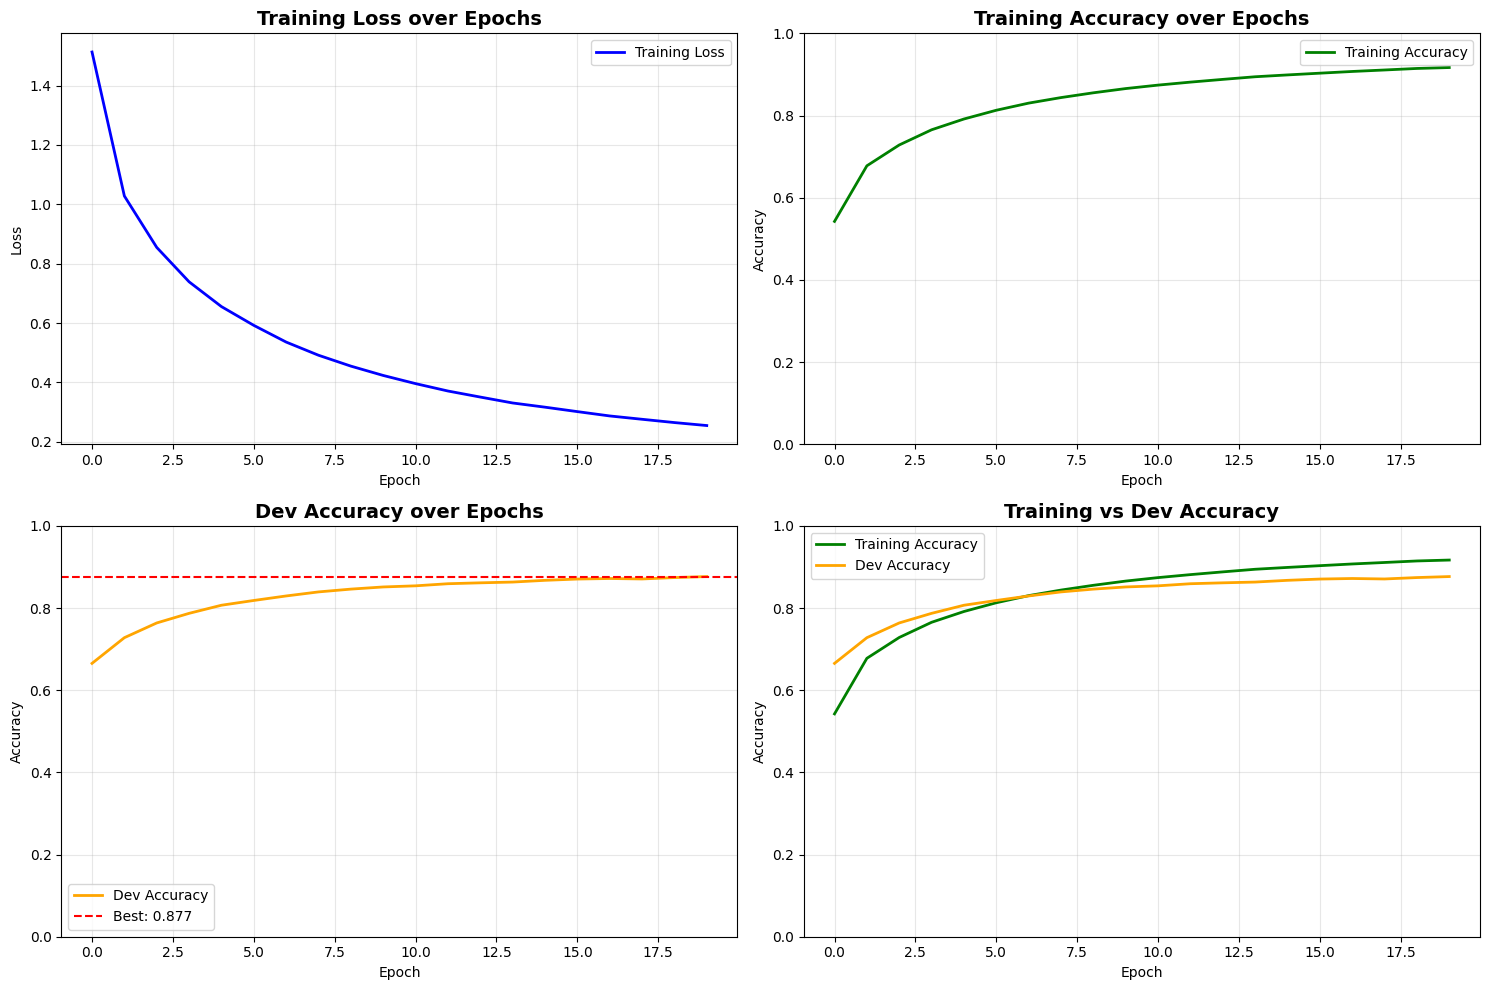

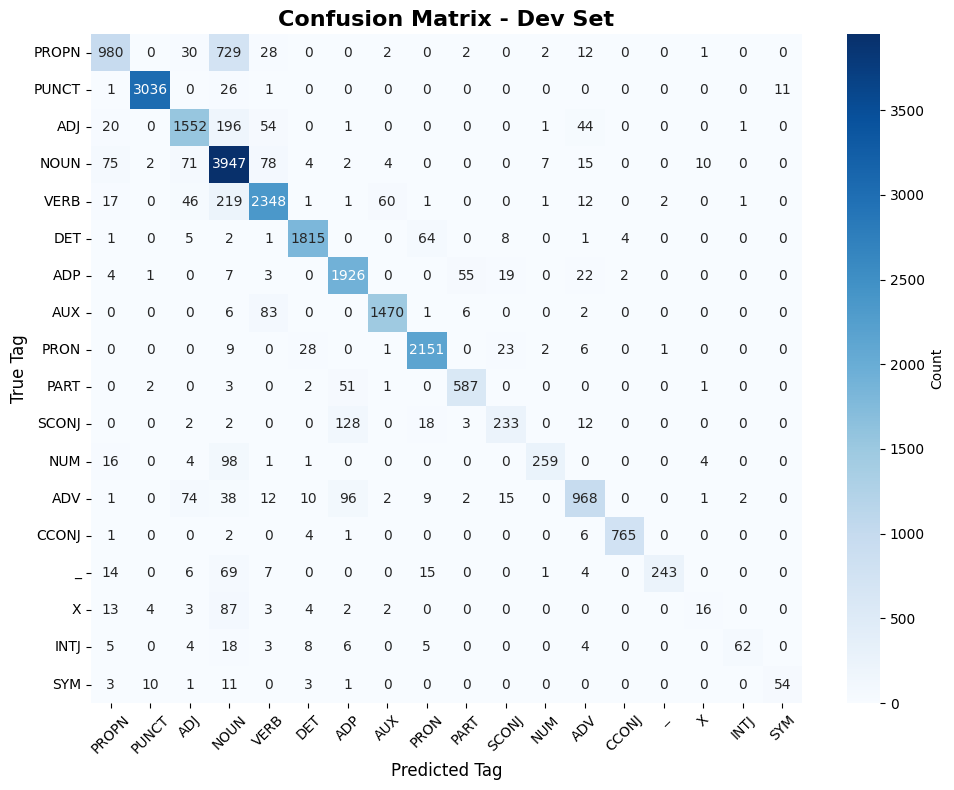


 Lỗi:
Top 10 lỗi:
  PROPN -> NOUN: 729 lan
  VERB -> NOUN: 219 lan
  ADJ -> NOUN: 196 lan
  SCONJ -> ADP: 128 lan
  NUM -> NOUN: 98 lan
  ADV -> ADP: 96 lan
  X -> NOUN: 87 lan
  AUX -> VERB: 83 lan
  NOUN -> VERB: 78 lan
  NOUN -> PROPN: 75 lan

 Ví dụ:
  1. Word: 'AP' | True: PROPN | Pred: NOUN
  2. Word: 'nominated' | True: VERB | Pred: PROPN
  3. Word: 'associate' | True: ADJ | Pred: NOUN
  4. Word: 'Superior' | True: ADJ | Pred: PROPN
  5. Word: '<UNK>' | True: PROPN | Pred: NOUN


In [9]:
plt.figure(figsize=(15, 10))

# Plot Loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
plt.title('Training Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Training Accuracy
plt.subplot(2, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', color='green', linewidth=2)
plt.title('Training Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

# Plot Dev Accuracy
plt.subplot(2, 2, 3)
plt.plot(dev_accuracies, label='Dev Accuracy', color='orange', linewidth=2)
plt.axhline(y=best_dev_accuracy, color='red', linestyle='--', label=f'Best: {best_dev_accuracy:.3f}')
plt.title('Dev Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

# Plot Combined Accuracy
plt.subplot(2, 2, 4)
plt.plot(train_accuracies, label='Training Accuracy', color='green', linewidth=2)
plt.plot(dev_accuracies, label='Dev Accuracy', color='orange', linewidth=2)
plt.title('Training vs Dev Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Confusion Matrix
if len(dev_targets_filtered) > 0 and len(dev_preds_filtered) > 0:
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(dev_targets_filtered, dev_preds_filtered)

    # Lọc bỏ tag <PAD>
    tag_names_filtered = [tag for tag in tag_names if tag != '<PAD>']

    # Tạo confusion matrix chỉ cho các tag không phải <PAD>
    mask = [i for i, tag in enumerate(ix_to_tag.values()) if tag != '<PAD>']
    cm_filtered = np.zeros((len(tag_names_filtered), len(tag_names_filtered)), dtype=int)

    for i, true_idx in enumerate(dev_targets_filtered):
        pred_idx = dev_preds_filtered[i]
        if true_idx in mask and pred_idx in mask:
            i_filtered = mask.index(true_idx)
            j_filtered = mask.index(pred_idx)
            cm_filtered[i_filtered, j_filtered] += 1

    sns.heatmap(cm_filtered, annot=True, fmt='d',
                xticklabels=tag_names_filtered,
                yticklabels=tag_names_filtered,
                cmap='Blues', cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - Dev Set', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Tag', fontsize=12)
    plt.ylabel('True Tag', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Phân tích lỗi
print("\n Lỗi:")
print("="*50)

# Tìm các trường hợp dự đoán sai trên dev set
error_analysis = []
model.eval()
with torch.no_grad():
    for batch_sentences, batch_tags, batch_lengths in dev_loader:
        batch_sentences = batch_sentences.to(device)
        batch_tags = batch_tags.to(device)

        outputs = model(batch_sentences, batch_lengths)
        predictions = torch.argmax(outputs, dim=2)

        for i, length in enumerate(batch_lengths):
            true_tags = batch_tags[i, :length].cpu().numpy()
            pred_tags = predictions[i, :length].cpu().numpy()

            # Lấy lại từ gốc
            sent_indices = batch_sentences[i, :length].cpu().numpy()
            words = [ix_to_word[idx] for idx in sent_indices]

            for j, (word, true_tag, pred_tag) in enumerate(zip(words, true_tags, pred_tags)):
                if true_tag != pred_tag and true_tag != pad_idx:
                    error_analysis.append({
                        'word': word,
                        'true_tag': ix_to_tag[true_tag],
                        'pred_tag': ix_to_tag[pred_tag],
                        'position': j
                    })

# Hiển thị 10 lỗi phổ biến nhất
from collections import Counter
error_counter = Counter((e['true_tag'], e['pred_tag']) for e in error_analysis)

print("Top 10 lỗi:")
for (true_tag, pred_tag), count in error_counter.most_common(10):
    print(f"  {true_tag} -> {pred_tag}: {count} lan")

# Hiển thị một vài ví dụ lỗi cụ thể
print("\n Ví dụ:")
for i, error in enumerate(error_analysis[:5]):
    print(f"  {i+1}. Word: '{error['word']}' | True: {error['true_tag']} | Pred: {error['pred_tag']}")